# Imputation Experiment Adult Census

## ???? ?????

???????? ??????? ?????? ??????? ????????? ????????? ?? ???????? Logistic Regression.

## ?????

`SimpleImputer median/mode` ? `KNNImputer` ??? ???????? ????????? ???? ?????????? ???????: Accuracy 0.8525, F1-score 0.6568 ? ROC-AUC 0.9040. ? ???? ???????????? ????? ??????? ????????? ?? ???? ????????, ??????? ??????? ?????? ???????? ????????????????: ?? ???????, ?????????? ? ????? ???????????.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "adult-census.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
RANDOM_STATE = 42

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression

from src.experiment_utils import (
    load_adult_data,
    split_features_target,
    get_feature_groups,
    calculate_metrics,
    save_results,
)

def get_positive_proba(model, X_test):
    positive_index = list(model.classes_).index(">50K")
    return model.predict_proba(X_test)[:, positive_index]

import matplotlib.pyplot as plt
import seaborn as sns
from src.experiment_utils import save_figure

sns.set_theme(style="whitegrid", context="notebook")

## ?????

`SimpleImputer median/mode` ? `KNNImputer` ??? ???????? ????????? ???? ?????????? ???????: Accuracy 0.8525, F1-score 0.6568 ? ROC-AUC 0.9040. ? ???? ???????????? ????? ??????? ????????? ?? ???? ????????, ??????? ??????? ?????? ???????? ????????????????: ?? ???????, ?????????? ? ????? ???????????.

In [2]:
df = load_adult_data(DATA_PATH)
X, y = split_features_target(df)
numeric_features, categorical_features = get_feature_groups(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

pd.DataFrame({"Numeric features": [len(numeric_features)], "Categorical features": [len(categorical_features)]})

,Numeric features,Categorical features
0,5,8


## ?????

`SimpleImputer median/mode` ? `KNNImputer` ??? ???????? ????????? ???? ?????????? ???????: Accuracy 0.8525, F1-score 0.6568 ? ROC-AUC 0.9040. ? ???? ???????????? ????? ??????? ????????? ?? ???? ????????, ??????? ??????? ?????? ???????? ????????????????: ?? ???????, ?????????? ? ????? ???????????.

In [3]:
imputation_variants = {
    "SimpleImputer median/mode": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]),
    "KNNImputer numeric": Pipeline([
        ("imputer", KNNImputer(n_neighbors=5)),
        ("scaler", StandardScaler()),
    ]),
}

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

list(imputation_variants.keys())

['SimpleImputer median/mode', 'KNNImputer numeric']

## ?????

`SimpleImputer median/mode` ? `KNNImputer` ??? ???????? ????????? ???? ?????????? ???????: Accuracy 0.8525, F1-score 0.6568 ? ROC-AUC 0.9040. ? ???? ???????????? ????? ??????? ????????? ?? ???? ????????, ??????? ??????? ?????? ???????? ????????????????: ?? ???????, ?????????? ? ????? ???????????.

In [4]:
rows = []

for preprocessing_name, numeric_transformer in imputation_variants.items():
    preprocessor = ColumnTransformer([
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ])
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=3000, solver="liblinear")),
    ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = get_positive_proba(model, X_test)
    rows.append({
        "Dataset": "Adult",
        "Experiment": "Imputation",
        "Model": "LogisticRegression",
        "Preprocessing": preprocessing_name,
        **calculate_metrics(y_test, y_pred, y_proba),
    })

imputation_results = pd.DataFrame(rows).round(4)
save_results(imputation_results, RESULTS_DIR / "imputation_results.csv")
imputation_results

,Dataset,Experiment,Model,Preprocessing,Accuracy,F1-score,ROC-AUC
0,Adult,Imputation,LogisticRegression,SimpleImputer median/mode,0.8525,0.6568,0.904
1,Adult,Imputation,LogisticRegression,KNNImputer numeric,0.8525,0.6568,0.904


## ?????

`SimpleImputer median/mode` ? `KNNImputer` ??? ???????? ????????? ???? ?????????? ???????: Accuracy 0.8525, F1-score 0.6568 ? ROC-AUC 0.9040. ? ???? ???????????? ????? ??????? ????????? ?? ???? ????????, ??????? ??????? ?????? ???????? ????????????????: ?? ???????, ?????????? ? ????? ???????????.

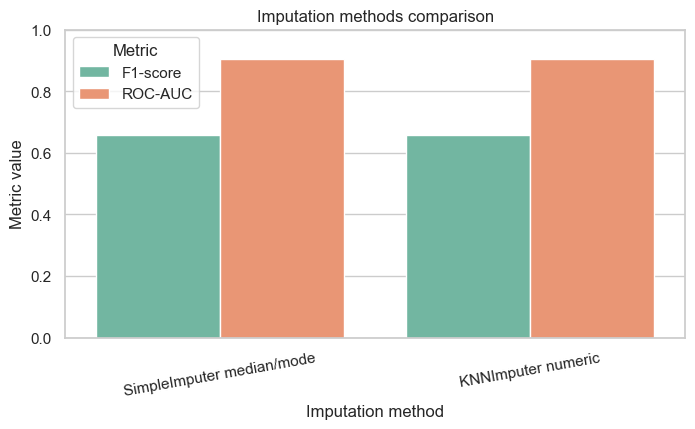

In [5]:
plot_df = imputation_results.melt(
    id_vars=["Preprocessing"],
    value_vars=["F1-score", "ROC-AUC"],
    var_name="Metric",
    value_name="Value",
)

plt.figure(figsize=(8, 4))
sns.barplot(data=plot_df, x="Preprocessing", y="Value", hue="Metric", palette="Set2")
plt.ylim(0, 1)
plt.title("Imputation methods comparison")
plt.xlabel("Imputation method")
plt.ylabel("Metric value")
plt.xticks(rotation=10)
save_figure(FIGURES_DIR / "imputation_comparison.png")
plt.show()

## ?????

`SimpleImputer median/mode` ? `KNNImputer` ??? ???????? ????????? ???? ?????????? ???????: Accuracy 0.8525, F1-score 0.6568 ? ROC-AUC 0.9040. ? ???? ???????????? ????? ??????? ????????? ?? ???? ????????, ??????? ??????? ?????? ???????? ????????????????: ?? ???????, ?????????? ? ????? ???????????.